# Data Exploration

Goal: Understand the structure of `subjects.csv` and `physiological.csv` before feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

subjects = pd.read_csv("data/preprocessed/subjects.csv")
physio = pd.read_csv("data/preprocessed/physiological.csv")

print("Subjects:", subjects.shape)
print("Physiological:", physio.shape)

Subjects: (495, 11)
Physiological: (8780579, 13)


## 1. Subject metadata overview

In [2]:
display(physio.head())
display(subjects.head())

,SubjectID,DeviceTimestamp,CycleID,Phase,PupilDiameter,GazeX,GazeY,GazeZ,PulseBPM,PPG_SQI,MotionMag,GazeAngleX,GazeAngleY
0,S001,0,1,baseline,3.556082,-0.008417,0.010767,0.999907,65.901791,0.857084,0.083383,-0.482296,0.616961
1,S001,16667,1,baseline,3.587611,-0.006079,0.009187,0.999939,65.901791,0.904661,0.060097,-0.348295,0.526407
2,S001,33334,1,baseline,3.587292,-0.007796,0.008181,0.999936,65.901791,0.921183,0.073527,-0.446724,0.468730
3,S001,50001,1,baseline,3.607923,-0.008068,0.009710,0.999920,65.901791,0.883678,0.063755,-0.462315,0.556372
4,S001,66668,1,baseline,3.611525,-0.008401,0.008371,0.999930,65.901791,0.895014,0.064652,-0.481357,0.479662


,SubjectID,STAI_T,STAI_S,Gender,Handedness,WearsGlasses,CalibrationError,BloodType,Gender_numeric,Handedness_numeric,BloodType_numeric
0,S001,37,36,F,R,0,0.396519,B,1,1,2
1,S003,40,39,M,R,1,0.270619,B,0,1,2
2,S004,34,30,M,L,1,0.387328,O,0,0,0
3,S005,25,40,M,R,0,0.263703,O,0,1,0
4,S006,28,29,F,L,0,0.140290,A,1,0,1


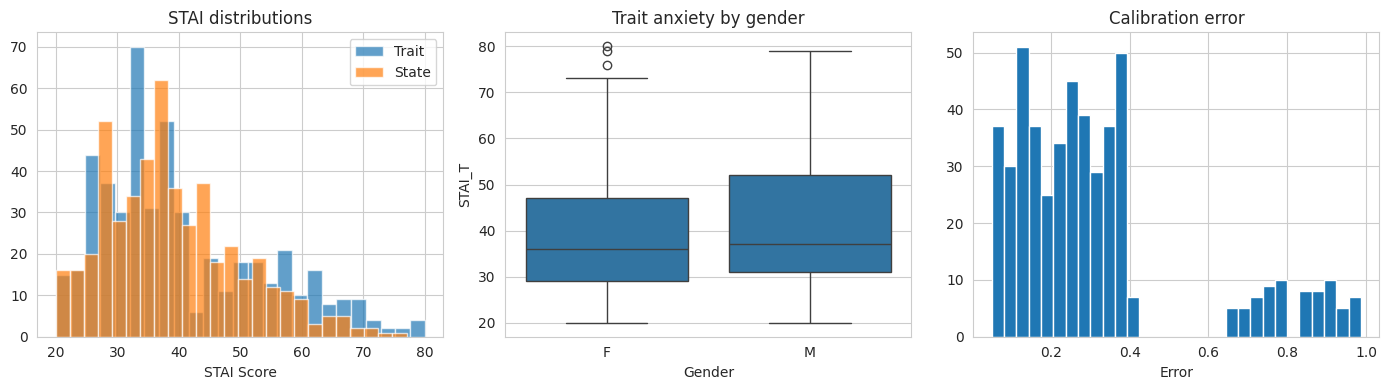

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# STAI distributions
axes[0].hist(subjects["STAI_T"], bins=25, alpha=0.7, label="Trait")
axes[0].hist(subjects["STAI_S"], bins=25, alpha=0.7, label="State")
axes[0].set_xlabel("STAI Score")
axes[0].legend()
axes[0].set_title("STAI distributions")

# Gender x Anxiety
sns.boxplot(data=subjects, x="Gender", y="STAI_T", ax=axes[1])
axes[1].set_title("Trait anxiety by gender")

# Calibration error distribution
axes[2].hist(subjects["CalibrationError"], bins=30)
axes[2].set_title("Calibration error")
axes[2].set_xlabel("Error")

plt.tight_layout()
plt.show()

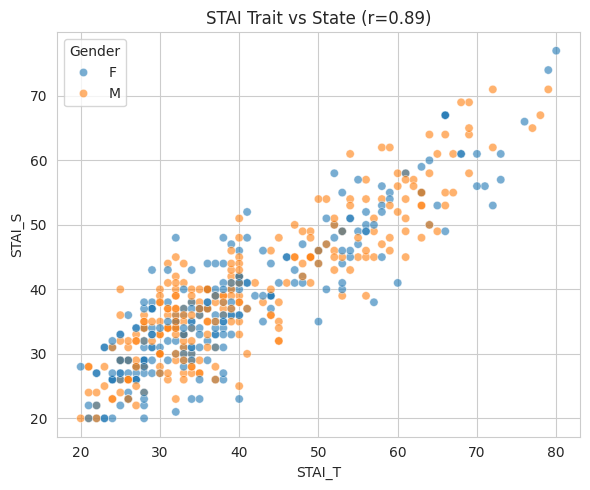

In [3]:
# STAI_T vs STAI_S correlation
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=subjects, x="STAI_T", y="STAI_S", hue="Gender", alpha=0.6, ax=ax)
ax.set_title(f"STAI Trait vs State (r={subjects['STAI_T'].corr(subjects['STAI_S']):.2f})")
plt.tight_layout()
plt.show()

## 2. Physiological data structure

Cycles per subject:
count    495.000000
mean       9.054545
std        1.761904
min        2.000000
25%        9.000000
50%       10.000000
75%       10.000000
max       10.000000
Name: CycleID, dtype: float64


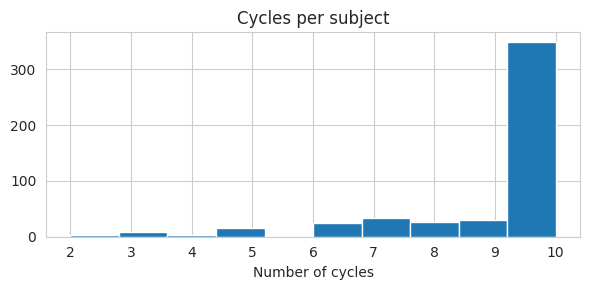

In [4]:
# How many cycles does each subject have?
cycles_per_subj = physio.groupby("SubjectID")["CycleID"].nunique()
print("Cycles per subject:")
print(cycles_per_subj.describe())

fig, ax = plt.subplots(figsize=(6, 3))
cycles_per_subj.hist(bins=10, ax=ax)
ax.set_xlabel("Number of cycles")
ax.set_title("Cycles per subject")
plt.tight_layout()
plt.show()

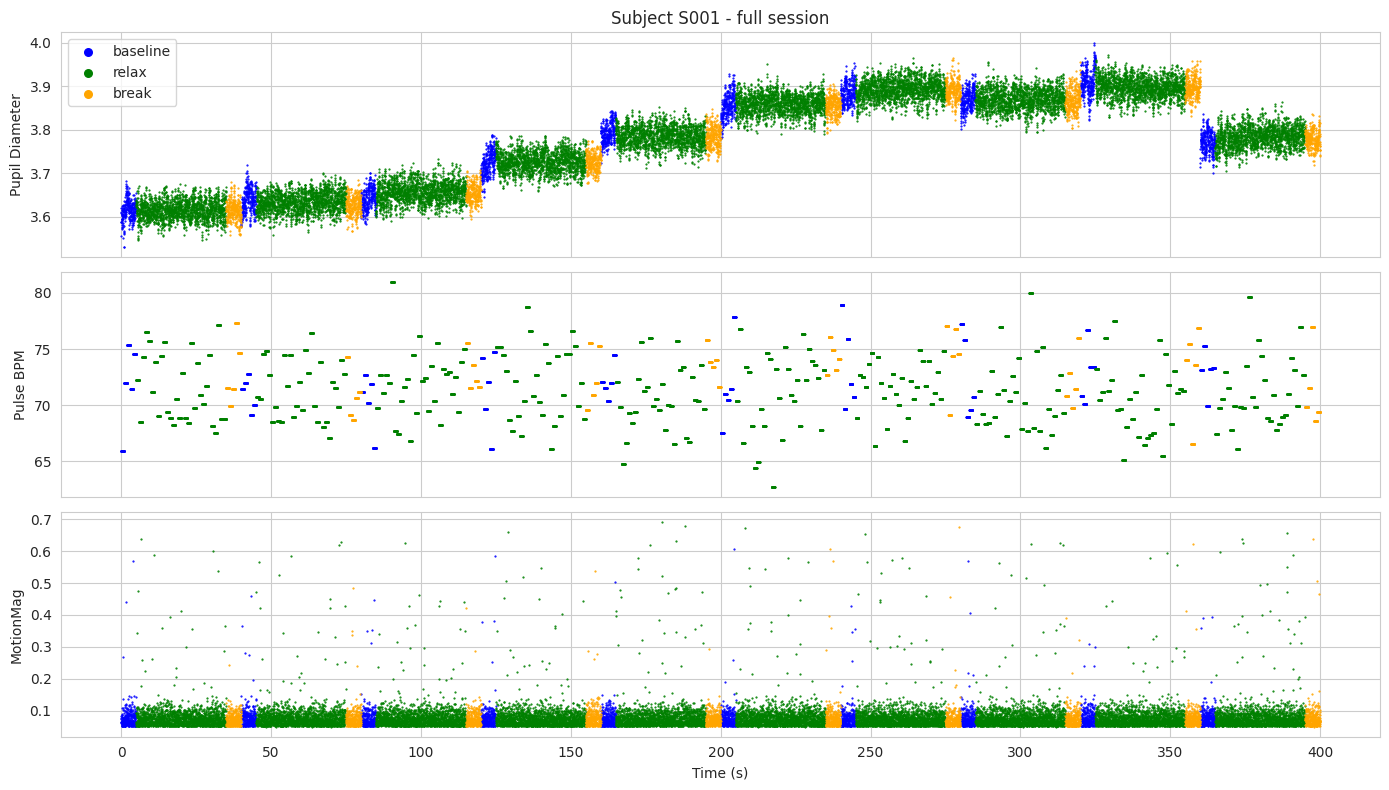

In [4]:
# Pick one subject to visualize the time series
subj = "S001"
s_data = physio[physio["SubjectID"] == subj].copy()
s_data["time_s"] = s_data["DeviceTimestamp"] / 1e6  # microseconds -> seconds

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Color by phase
colors = {"baseline": "blue", "relax": "green", "break": "orange"}
for phase, color in colors.items():
    mask = s_data["Phase"] == phase
    axes[0].scatter(s_data.loc[mask, "time_s"], s_data.loc[mask, "PupilDiameter"], s=0.3, c=color, label=phase)
    axes[1].scatter(s_data.loc[mask, "time_s"], s_data.loc[mask, "PulseBPM"], s=0.3, c=color)
    axes[2].scatter(s_data.loc[mask, "time_s"], s_data.loc[mask, "MotionMag"], s=0.3, c=color)

axes[0].set_ylabel("Pupil Diameter")
axes[0].legend(markerscale=10)
axes[0].set_title(f"Subject {subj} - full session")
axes[1].set_ylabel("Pulse BPM")
axes[2].set_ylabel("MotionMag")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

## 3. Phase-level distributions across all subjects

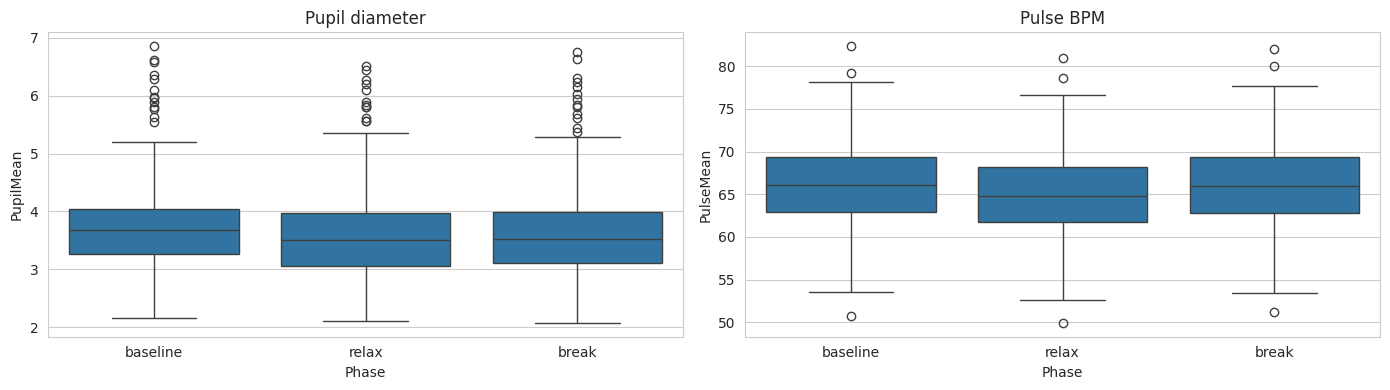

In [5]:
# Aggregate per subject per phase
phase_agg = physio.groupby(["SubjectID", "Phase"]).agg(
    PupilMean=("PupilDiameter", "mean"),
    PulseMean=("PulseBPM", "mean"),
    MotionMean=("MotionMag", "mean"),
    PPG_SQI_Mean=("PPG_SQI", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes, ["PupilMean", "PulseMean"],
                           ["Pupil diameter", "Pulse BPM"]):
    sns.boxplot(data=phase_agg, x="Phase", y=col, order=["baseline", "relax", "break"], ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 4. Temporal dynamics: do signals change across cycles?

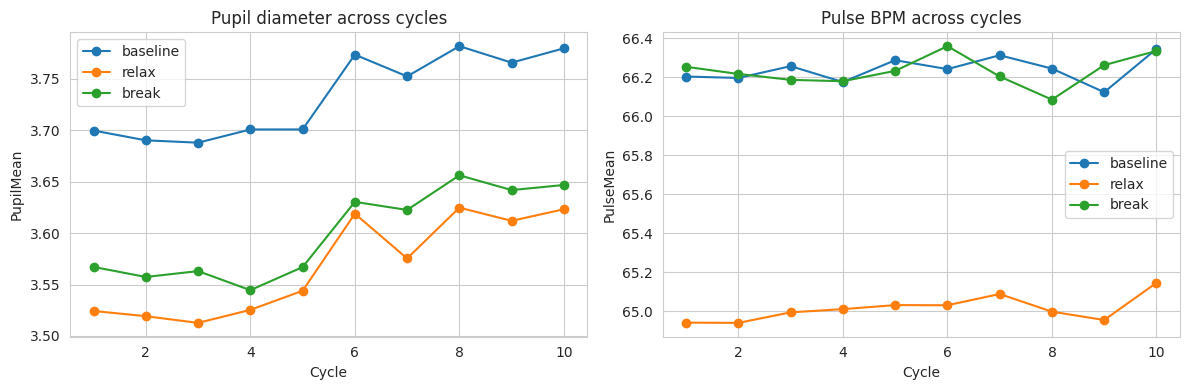

In [7]:
# Mean per subject per cycle per phase
cycle_agg = physio.groupby(["SubjectID", "CycleID", "Phase"]).agg(
    PupilMean=("PupilDiameter", "mean"),
    PulseMean=("PulseBPM", "mean"),
).reset_index()

# Average across subjects
cycle_trend = cycle_agg.groupby(["CycleID", "Phase"])[["PupilMean", "PulseMean"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["PupilMean", "PulseMean"], ["Pupil diameter", "Pulse BPM"]):
    for phase in ["baseline", "relax", "break"]:
        d = cycle_trend[cycle_trend["Phase"] == phase]
        ax.plot(d["CycleID"], d[col], marker="o", label=phase)
    ax.set_xlabel("Cycle")
    ax.set_ylabel(col)
    ax.set_title(f"{title} across cycles")
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Gaze patterns

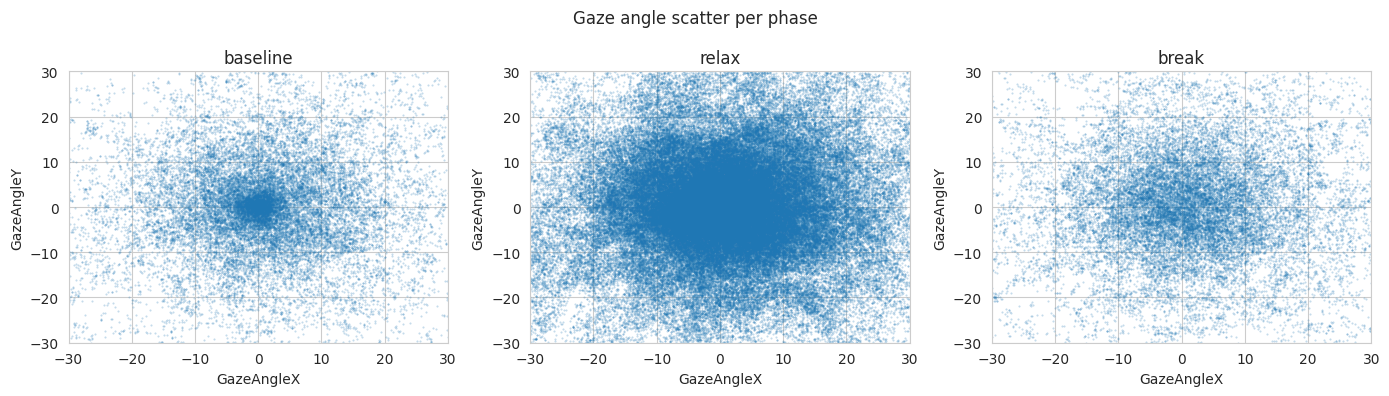

In [6]:
# Gaze angle distributions per phase (sample to avoid memory issues)
sample = physio.sample(n=200_000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, phase in zip(axes, ["baseline", "relax", "break"]):
    d = sample[sample["Phase"] == phase]
    ax.scatter(d["GazeAngleX"], d["GazeAngleY"], s=0.2, alpha=0.3)
    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_title(phase)
    ax.set_xlabel("GazeAngleX")
    ax.set_ylabel("GazeAngleY")
plt.suptitle("Gaze angle scatter per phase")
plt.tight_layout()
plt.show()

## 6. Individual variability: how different are subjects?

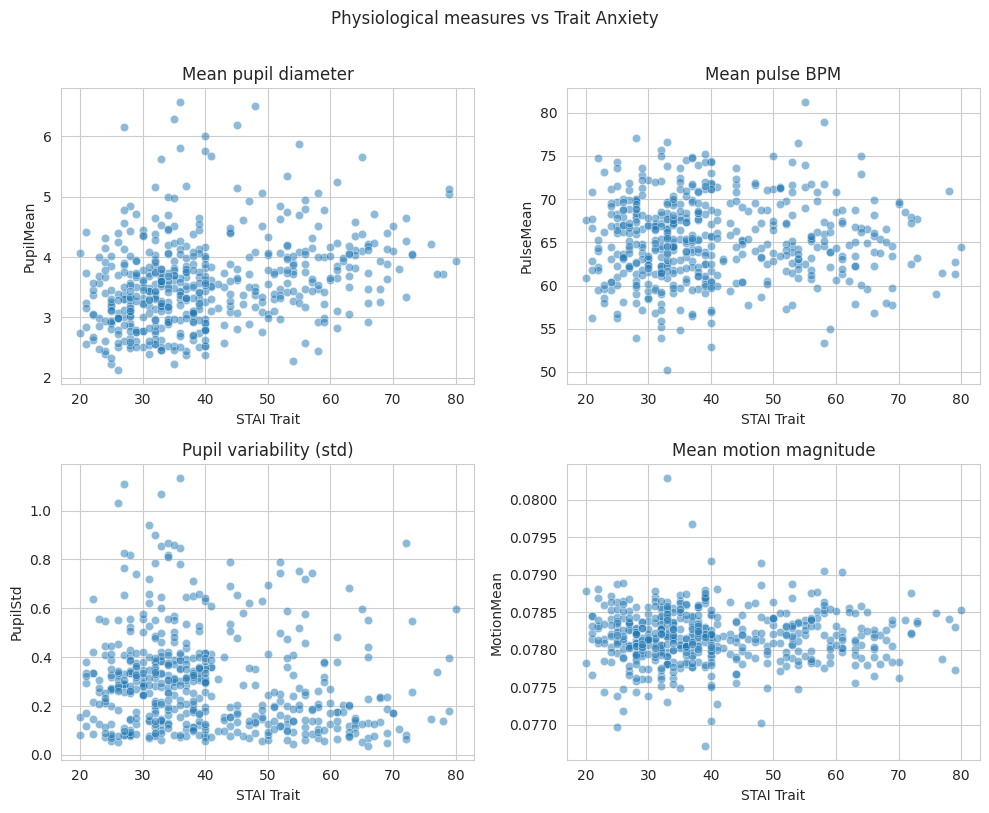

In [8]:
# Per-subject overall means
subj_means = physio.groupby("SubjectID").agg(
    PupilMean=("PupilDiameter", "mean"),
    PupilStd=("PupilDiameter", "std"),
    PulseMean=("PulseBPM", "mean"),
    PulseStd=("PulseBPM", "std"),
    MotionMean=("MotionMag", "mean"),
).reset_index()

subj_means = subj_means.merge(subjects[["SubjectID", "STAI_T", "STAI_S"]], on="SubjectID")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.scatterplot(data=subj_means, x="STAI_T", y="PupilMean", alpha=0.5, ax=axes[0, 0])
sns.scatterplot(data=subj_means, x="STAI_T", y="PulseMean", alpha=0.5, ax=axes[0, 1])
sns.scatterplot(data=subj_means, x="STAI_T", y="PupilStd", alpha=0.5, ax=axes[1, 0])
sns.scatterplot(data=subj_means, x="STAI_T", y="MotionMean", alpha=0.5, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xlabel("STAI Trait")

axes[0, 0].set_title("Mean pupil diameter")
axes[0, 1].set_title("Mean pulse BPM")
axes[1, 0].set_title("Pupil variability (std)")
axes[1, 1].set_title("Mean motion magnitude")
plt.suptitle("Physiological measures vs Trait Anxiety", y=1.01)
plt.tight_layout()
plt.show()